<a href="https://colab.research.google.com/github/MateDort/VesselView-/blob/main/VesselView2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:

# ── Core ──────────────────────────────────────────────────────
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

# ── PyTorch ───────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

# ── Segmentation model ─────────────────────────────────────────
import segmentation_models_pytorch as smp

# ── Image processing ───────────────────────────────────────────
import cv2  # OpenCV — for CLAHE contrast enhancement

# ── Device ────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")

Device: cuda
PyTorch: 2.11.0+cu128


### Config settings for easy change

In [57]:
CONFIG = {
    #Data
    "image_size": 512,
    "batch_size": 4,

    #Training
    "epochs": 150,
    "learning_rate": 1e-4,
    "patience": 10,

    #Model
    "encoder": "resnet34",
    "encoder_weights": "imagenet",

    #Paths
    "data_dir": "/content/drive/MyDrive/DRIVE",
    "save_dir": "/content/drive/MyDrive/DRIVE",

    #Reproducibility
    "seed": 42,
}

# Set seed — so results are reproducible every run
def set_seed(seed):
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed(seed)

set_seed(CONFIG["seed"])
print("Config ready")
print(f"Training for {CONFIG['epochs']} epochs on {device}")

Config ready
Training for 150 epochs on cuda


### Mount and check for the dataset in google drive

In [58]:
from google.colab import drive
import os

# Mount Google Drive to the standard /content/drive location
drive.mount('/content/drive')

# Define the expected path for data, as per your CONFIG
data_path = '/content/drive/MyDrive/DRIVE'

# Check if the data directory exists after mounting
if os.path.exists(data_path):
  print(f"Google Drive mounted successfully and data directory '{data_path}' is accessible.")
else:
  print(f"Google Drive mounted, but data directory '{data_path}' not found. Please ensure it exists in your Google Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully and data directory '/content/drive/MyDrive/DRIVE' is accessible.


### example of the dataset Fundus picture and Segmentation

 Image shape: (584, 565, 3)
 Mask shape: (584, 565)


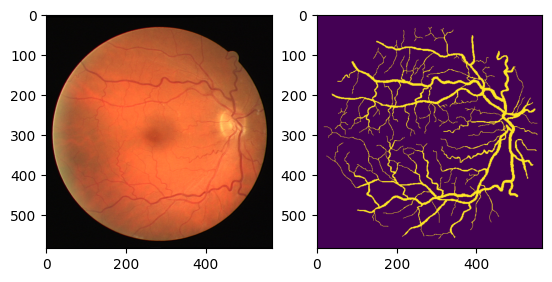

In [59]:
test_mask_path = '/content/drive/MyDrive/DRIVE/training/1st_manual/22_manual1.gif'
test_image_path = '/content/drive/MyDrive/DRIVE/training/images/22_training.tif'

mask = np.array( Image.open( test_mask_path ) )
image = np.array( Image.open( test_image_path ) )

print(f" Image shape: {image.shape}")
print(f" Mask shape: {mask.shape}")

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.subplot(1, 2, 2)
plt.imshow(mask)

### Number of pixels of background and vessels

In [60]:
ones_zeros = mask > 0
blood_vessel = ones_zeros.sum()
background = (ones_zeros == False).sum()
total = blood_vessel + background
print(f"Vessel: {blood_vessel}")
print(f"Background: {background}")
print(f"total count: {total}")
print(f"percantage of vessels: {blood_vessel/total*100}")
print(f"percantage of background: {background/total*100}")

Vessel: 29809
Background: 300151
total count: 329960
percantage of vessels: 9.034125348527095
percantage of background: 90.96587465147292


### vessels are roughly 9% of all pixels. Background is 91%.

In [61]:
class DriveDataset(Dataset):
  def __init__(self, image_dir,mask_dir, transform=None, file_list=None):
    self.image_dir = image_dir
    self.mask_dir = mask_dir
    self.transform = transform

    if file_list is not None:
      self.images = file_list
    else:
      self.images = os.listdir(image_dir)

  def __len__(self):
    return len(self.images)

  def __getitem__(self, index):
    mask_path = os.path.join(self.mask_dir, self.images[index])
    img_path = os.path.join(self.image_dir, self.images[index].replace("_manual1.gif", "_training.tif"))
    image = np.array(Image.open(img_path).convert("RGB"))
    mask = np.array(Image.open(mask_path).convert("L"), dtype=np.float32)
    mask[mask == 255.0] = 1.0
    if self.transform is not None:
      augmentations = self.transform(image=image, mask=mask)
      image = augmentations["image"]
      mask = augmentations["mask"]
    return image, mask


In [62]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([
    A.Resize(width=512, height=512),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Rotate((-15, 15), p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

test_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])



In [63]:
image_dir = "/content/drive/MyDrive/DRIVE/training/images/"
mask_dir = "/content/drive/MyDrive/DRIVE/training/1st_manual/"

all_files = sorted([f for f in os.listdir(mask_dir) if f.endswith('.gif')])
random.shuffle(all_files)

val_files = all_files[:4]
train_files = all_files[4:]

train_dataset = DriveDataset(image_dir, mask_dir, transform=train_transform, file_list=train_files)
val_dataset = DriveDataset(image_dir, mask_dir, transform=test_transform, file_list=val_files)

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
)

In [64]:
images, masks = next(iter(train_loader))
print(images.shape)
print(masks.shape)

torch.Size([4, 3, 512, 512])
torch.Size([4, 512, 512])


In [65]:
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    decoder_droupout=0.2,
)
for param in model.parameters():
  param.requires_grad = True
model = model.to(device)


In [66]:
dice_loss = smp.losses.DiceLoss(mode="binary")
bce_loss = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=CONFIG["learning_rate"])

print(f'dice_loss: {dice_loss}')
print(f'bce_loss: {bce_loss}')
print(f'optimizer: {optimizer}')

dice_loss: DiceLoss()
bce_loss: BCEWithLogitsLoss()
optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


In [67]:
epochs = CONFIG["epochs"]
best_val_loss = float('inf')
patience = 3
epochs_no_improve=0
train_losses = []
val_losses = []
loaders = {'train': train_loader, 'val': val_loader}
for epoch in range(epochs):
    stopped_early = False
    for phase in ['train', 'val']:
        if phase == 'train':
            model.train() # set model to train mode
        else:
            model.eval()# set model to eval mode

        running_loss = 0.0


        for images, masks in loaders[phase]:
            images = images.to(device)
            masks = masks.to(device)
            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                output = model(images)
                loss = bce_loss(output.squeeze(1), masks) + dice_loss(output.squeeze(1), masks)

                if phase == 'train':
                    loss.backward()  # backprop
                    optimizer.step()  # optimizer step

            running_loss += loss.item()

        avg_loss = running_loss / len(loaders[phase])
        if phase == 'train':
            train_losses.append(avg_loss)
        elif phase == 'val':
            val_losses.append(avg_loss)

        if phase == 'val':
         if avg_loss < best_val_loss:
            epochs_no_improve = 0
            best_val_loss = avg_loss
            print("epochs improve back to zero")
         else:
            epochs_no_improve += 1
            print(f"number of no epochs not improved: {epochs_no_improve}")

         if epochs_no_improve == patience:
            print("overfitting started! stopping early")
            stopped_early = True
            break


        print(f"Epoch {epoch+1}/{epochs} | {phase} loss: {avg_loss:.4f}")
    if stopped_early:
     break

print("Training done!")

Epoch 1/150 | train loss: 1.7223
epochs improve back to zero
Epoch 1/150 | val loss: 2.4032
Epoch 2/150 | train loss: 1.6231
number of no epochs not improved: 1
Epoch 2/150 | val loss: 2.4450
Epoch 3/150 | train loss: 1.5489
epochs improve back to zero
Epoch 3/150 | val loss: 2.1228
Epoch 4/150 | train loss: 1.4906
epochs improve back to zero
Epoch 4/150 | val loss: 1.8344
Epoch 5/150 | train loss: 1.4563
epochs improve back to zero
Epoch 5/150 | val loss: 1.6053
Epoch 6/150 | train loss: 1.4200
epochs improve back to zero
Epoch 6/150 | val loss: 1.5552
Epoch 7/150 | train loss: 1.3658
epochs improve back to zero
Epoch 7/150 | val loss: 1.4329
Epoch 8/150 | train loss: 1.3564
epochs improve back to zero
Epoch 8/150 | val loss: 1.3953
Epoch 9/150 | train loss: 1.3223
number of no epochs not improved: 1
Epoch 9/150 | val loss: 1.4418
Epoch 10/150 | train loss: 1.2835
epochs improve back to zero
Epoch 10/150 | val loss: 1.3485
Epoch 11/150 | train loss: 1.2622
epochs improve back to zero


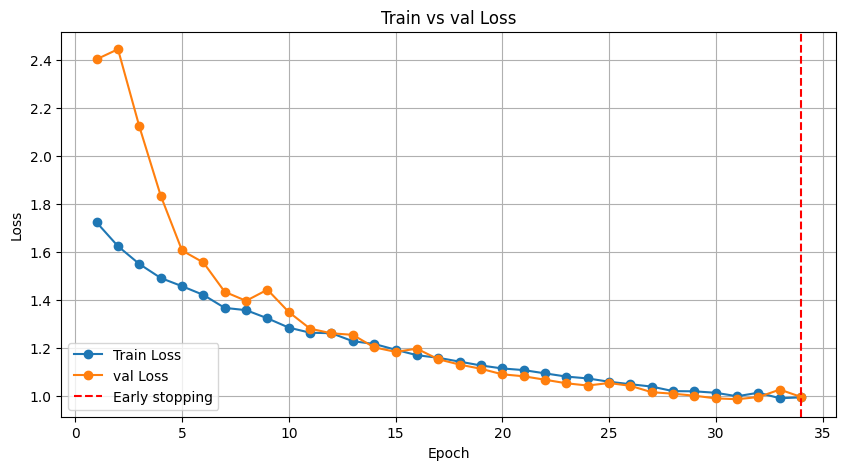

In [68]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_losses)+1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, len(val_losses)+1), val_losses,  label='val Loss',  marker='o')
plt.axvline(x=len(train_losses), color='red', linestyle='--', label='Early stopping')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train vs val Loss')
plt.legend()
plt.grid(True)
plt.show()

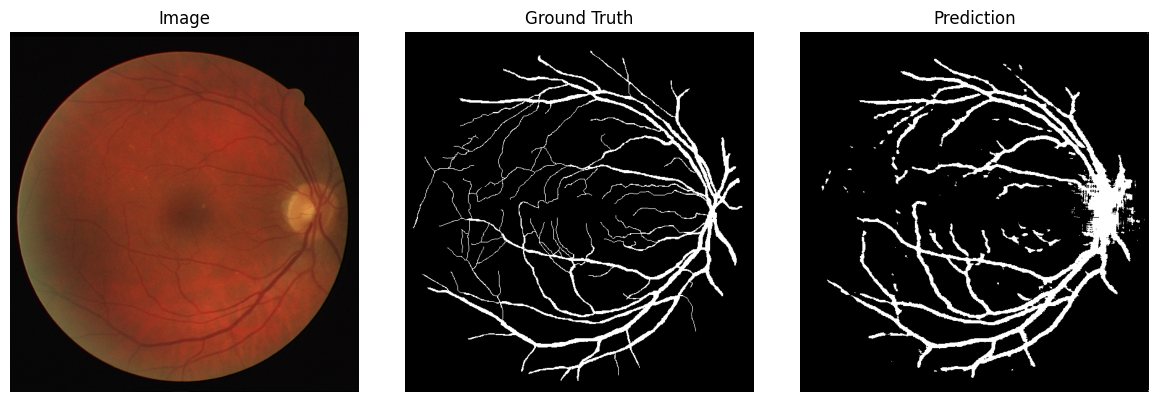

In [69]:
model.eval()

images, masks = next(iter(val_loader))
images = images.to(device)

with torch.no_grad():
    output = model(images)
    preds = torch.sigmoid(output.squeeze(1))
    preds = (preds > 0.5).float()

# Denormalize image for display
mean = torch.tensor([0.485, 0.456, 0.406])
std  = torch.tensor([0.229, 0.224, 0.225])

for i in range(len(images)):
    img = images[i].cpu().permute(1, 2, 0)
    img = img * std + mean
    img = img.clamp(0, 1)

    gt   = masks[i].cpu().numpy()
    pred = preds[i].cpu().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img);             axes[0].set_title("Image");      axes[0].axis("off")
    axes[1].imshow(gt,   cmap="gray"); axes[1].set_title("Ground Truth"); axes[1].axis("off")
    axes[2].imshow(pred, cmap="gray"); axes[2].set_title("Prediction");   axes[2].axis("off")
    plt.tight_layout()
    plt.show()